In [27]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import os
from matplotlib.lines import Line2D
import pdfkit

In [2]:
model_map = {
    "clip": "CLIP",
    "convnext": "ConvNeXt V2",
    "deit": "DeiT III",
    "dino": "DINOv2",
    "mae": "MAE",
    "resnet": "ResNet-50",
    "siglip": "SigLIP",
    "swin": "Swin V2"
}

region_map = {
    # DollarStreet region codes
    "af": "Africa",
    "eu": "Europe",
    "am": "Americas",
    "as": "Asia",

    # GeoDE region names
    "Africa": "Africa",
    "Europe": "Europe",
    "Americas": "Americas",
    "EastAsia": "East Asia",
    "WestAsia": "West Asia",
    "SouthEastAsia": "Southeast Asia"
}

In [3]:
def finetune_results(root_path):
    df = pd.DataFrame({
        'dataset': [], 'model': [], 
        'loss': [], 'object_acc': [], 'best_region': [], 'worst_region': [], 
        'best_region_acc': [], 'worst_region_acc': [], 'region_bias_gap': [], 'finetune': [],
    })

    for dataset in os.listdir(root_path):
        if dataset != 'imagenet':
            dataset_path = os.path.join(root_path, dataset)
            for model in os.listdir(dataset_path):
                model_path = os.path.join(dataset_path, model)
                for file in os.listdir(model_path):
                    if "results" in file:
                        result_path = os.path.join(model_path, file)

                        with open(result_path, 'r') as f:
                            data_dict = json.load(f)
                            df.loc[len(df)] = [
                                dataset,
                                model,
                                data_dict['loss'],
                                data_dict['object_acc'],
                                data_dict['best_region'],
                                data_dict['worst_region'],
                                data_dict['best_region_acc'],
                                data_dict['worst_region_acc'],
                                data_dict['region_bias_gap'],
                                'yes'
                            ]
        else:
            dataset_path = os.path.join(root_path, dataset)
            for file in os.listdir(dataset_path):
                result_path = os.path.join(dataset_path, file)
                dataset = file.split('_')[0]
                model = file.split('_')[1][:-5]
                with open(result_path, 'r') as f:
                    data_dict = json.load(f)['splits']['test']
                    df.loc[len(df)] = [
                        dataset,
                        model,
                        data_dict['loss'],
                        data_dict['object_acc'],
                        data_dict['best_region'],
                        data_dict['worst_region'],
                        data_dict['best_region_acc'],
                        data_dict['worst_region_acc'],
                        data_dict['region_bias_gap'],
                        'no'
                    ]

    df["model"] = df["model"].map(model_map)

    for col in ["best_region", "worst_region"]:
        df[col] = df[col].replace(region_map)

    metrics = ["object_acc", "best_region_acc", "worst_region_acc", "region_bias_gap"]

    df = df.copy()
    df[metrics] = round(df[metrics] * 100, 2)

    return df

In [4]:
root_path = r"D:\Project\DAP_paper\results"
results = finetune_results(root_path)
results

,dataset,model,loss,object_acc,best_region,worst_region,best_region_acc,worst_region_acc,region_bias_gap,finetune
0,dollarstreet,CLIP,1.562710,73.05,Europe,Africa,77.84,67.77,10.07,yes
1,dollarstreet,ConvNeXt V2,1.427907,76.67,Europe,Africa,80.61,72.14,8.48,yes
2,dollarstreet,DeiT III,1.517757,75.12,Europe,Africa,78.57,69.66,8.91,yes
3,dollarstreet,DINOv2,1.563309,73.40,Europe,Africa,76.68,68.95,7.73,yes
4,dollarstreet,MAE,1.732312,66.74,Europe,Africa,69.10,62.22,6.88,yes
5,dollarstreet,ResNet-50,2.005920,58.87,Europe,Africa,63.56,51.36,12.20,yes
6,dollarstreet,SigLIP,1.458432,76.21,Europe,Africa,79.45,72.02,7.43,yes
7,dollarstreet,Swin V2,1.469359,76.09,Europe,Africa,79.15,71.90,7.25,yes
8,geode,CLIP,0.817028,95.38,West Asia,Southeast Asia,96.83,93.77,3.06,yes
9,geode,ConvNeXt V2,0.782145,96.61,West Asia,Southeast Asia,97.88,95.59,2.29,yes


In [5]:
def filter_df(df, dataset=None, finetuned=False):
    finetune_value = "yes" if finetuned else "no"

    filtered = df.copy()

    if dataset is not None:
        filtered = filtered[filtered["dataset"] == dataset]

    filtered = filtered[filtered["finetune"] == finetune_value]

    filtered = filtered.reset_index(drop=True)

    filtered = filtered.drop(
        columns=["dataset", "finetune", "loss"],
        errors="ignore"
    )

    return filtered

In [30]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

TABLE_DIR = Path("tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def clean_table_for_pdf(df):
    df = df.copy()

    # Format numeric columns nicely
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].round(2)

    # Convert everything to string for display
    df = df.fillna("").astype(str)

    return df


def export_df_to_pdf(df, title, output_path):
    df = clean_table_for_pdf(df)

    n_rows, n_cols = df.shape

    # Dynamic page height based on number of rows
    fig_width = 16
    fig_height = max(5, 1.2 + n_rows * 0.45)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # Title
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)

    # Style header and cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#B0B0B0")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_facecolor("#1F2937")
            cell.set_text_props(color="white", weight="bold")
        else:
            if row % 2 == 0:
                cell.set_facecolor("#F3F4F6")
            else:
                cell.set_facecolor("white")

    plt.tight_layout()

    with PdfPages(output_path) as pdf:
        pdf.savefig(fig, bbox_inches="tight")

    plt.close(fig)


exports = [
    (
        filter_df(results, dataset="geode", finetuned=True),
        "GeoDE - Finetuned Results",
        TABLE_DIR / "geode_finetuned.pdf"
    ),
    (
        filter_df(results, dataset="geode", finetuned=False),
        "GeoDE - Pretrained Results",
        TABLE_DIR / "geode_pretrained.pdf"
    ),
    (
        filter_df(results, dataset="dollarstreet", finetuned=True),
        "Dollar Street - Finetuned Results",
        TABLE_DIR / "dollar_finetuned.pdf"
    ),
    (
        filter_df(results, dataset="dollarstreet", finetuned=False),
        "Dollar Street - Pretrained Results",
        TABLE_DIR / "dollar_pretrained.pdf"
    ),
]

for df, title, path in exports:
    export_df_to_pdf(df, title, path)
    print(f"Saved: {path}")

Saved: tables\geode_finetuned.pdf
Saved: tables\geode_pretrained.pdf
Saved: tables\dollar_finetuned.pdf
Saved: tables\dollar_pretrained.pdf


In [ ]:
r"D:\Project\DAP_paper\notebooks\tables\geode_pretrained/pdf"

In [7]:
geode_finetuned

,model,object_acc,best_region,worst_region,best_region_acc,worst_region_acc,region_bias_gap
0,CLIP,95.38,West Asia,Southeast Asia,96.83,93.77,3.06
1,ConvNeXt V2,96.61,West Asia,Southeast Asia,97.88,95.59,2.29
2,DeiT III,96.28,West Asia,Southeast Asia,97.20,95.20,2.00
3,DINOv2,95.95,West Asia,Southeast Asia,97.14,94.77,2.38
4,MAE,92.86,West Asia,Southeast Asia,93.92,92.05,1.87
5,ResNet-50,90.86,Europe,Southeast Asia,92.38,89.72,2.66
6,SigLIP,95.91,West Asia,Southeast Asia,97.30,94.52,2.78
7,Swin V2,96.25,West Asia,Southeast Asia,97.41,95.31,2.10


In [8]:
geode_pretrained

,model,object_acc,best_region,worst_region,best_region_acc,worst_region_acc,region_bias_gap
0,CLIP,4.51,East Asia,West Asia,4.98,3.33,1.65
1,ConvNeXt V2,2.39,Americas,East Asia,2.87,1.80,1.07
2,DeiT III,1.77,Southeast Asia,Americas,1.93,1.54,0.39
3,DINOv2,2.10,Southeast Asia,West Asia,2.62,1.53,1.08
4,MAE,3.29,Southeast Asia,Africa,4.37,2.57,1.80
5,ResNet-50,2.82,Americas,Africa,3.51,2.13,1.38
6,SigLIP,2.52,West Asia,Europe,3.12,1.99,1.13
7,Swin V2,2.03,Europe,Africa,2.38,1.71,0.67


In [9]:
dollar_finetuned

,model,object_acc,best_region,worst_region,best_region_acc,worst_region_acc,region_bias_gap
0,CLIP,73.05,Europe,Africa,77.84,67.77,10.07
1,ConvNeXt V2,76.67,Europe,Africa,80.61,72.14,8.48
2,DeiT III,75.12,Europe,Africa,78.57,69.66,8.91
3,DINOv2,73.40,Europe,Africa,76.68,68.95,7.73
4,MAE,66.74,Europe,Africa,69.10,62.22,6.88
5,ResNet-50,58.87,Europe,Africa,63.56,51.36,12.20
6,SigLIP,76.21,Europe,Africa,79.45,72.02,7.43
7,Swin V2,76.09,Europe,Africa,79.15,71.90,7.25


In [10]:
dollar_pretrained

,model,object_acc,best_region,worst_region,best_region_acc,worst_region_acc,region_bias_gap
0,CLIP,1.46,Europe,Africa,1.75,1.18,0.57
1,ConvNeXt V2,1.60,Americas,Africa,2.34,1.06,1.27
2,DeiT III,1.90,Asia,Americas,2.08,1.52,0.57
3,DINOv2,1.07,Africa,Europe,1.53,0.44,1.10
4,MAE,2.60,Americas,Europe,2.92,2.19,0.73
5,ResNet-50,2.25,Europe,Americas,2.62,1.99,0.64
6,SigLIP,1.65,Asia,Europe,1.82,1.31,0.51
7,Swin V2,1.86,Africa,Asia,2.24,1.62,0.63


In [11]:
def detailed_results(root_path, dataset=None, imagenet=False):
    for dataset in ([dataset] if dataset else os.listdir(root_path)):
        if dataset == 'geode' and imagenet == False:
            df = pd.DataFrame({'dataset': [], 'model': [], 'Africa': [], 'Americas': [], 'EastAsia': [], 'Europe': [], 'SouthEastAsia': [], 'WestAsia': []})
            dataset_path = os.path.join(root_path, dataset)
            for model in os.listdir(dataset_path):
                model_path = os.path.join(dataset_path, model)
                for file in os.listdir(model_path):
                    if "results" in file:
                        result_path = os.path.join(model_path, file)
                        with open(result_path, 'r') as f:
                            data_dict = json.load(f)
                            df.loc[len(df)] = [
                                dataset,
                                model,
                                data_dict['region_object_acc']['Africa'],
                                data_dict['region_object_acc']['Americas'],
                                data_dict['region_object_acc']['EastAsia'],
                                data_dict['region_object_acc']['Europe'],
                                data_dict['region_object_acc']['SouthEastAsia'],
                                data_dict['region_object_acc']['WestAsia'],
                            ]

        elif dataset == 'dollarstreet' and imagenet == False:
            df = pd.DataFrame({'dataset': [], 'model': [], 'Africa': [], 'Americas': [], 'Asia': [], 'Europe': []})
            dataset_path = os.path.join(root_path, dataset)
            for model in os.listdir(dataset_path):
                model_path = os.path.join(dataset_path, model)
                for file in os.listdir(model_path):
                    if "results" in file:
                        result_path = os.path.join(model_path, file)
                        with open(result_path, 'r') as f:
                            data_dict = json.load(f)
                            df.loc[len(df)] = [
                                dataset,
                                model,
                                data_dict['region_object_acc']['af'],
                                data_dict['region_object_acc']['am'],
                                data_dict['region_object_acc']['as'],
                                data_dict['region_object_acc']['eu'],
                            ]

        elif dataset == 'geode' and imagenet == True:
            df = pd.DataFrame({'dataset': [], 'model': [], 'Africa': [], 'Americas': [], 'EastAsia': [], 'Europe': [], 'SouthEastAsia': [], 'WestAsia': []})
            dataset_path = os.path.join(root_path, 'imagenet')
            for file in os.listdir(dataset_path):
                if not file.endswith(".json"):
                    continue

                dataset_name = file.split('_')[0]

                if dataset_name != dataset:
                    continue

                result_path = os.path.join(dataset_path, file)
                model = file.split('_')[1][:-5]

                with open(result_path, 'r') as f:
                    data_dict = json.load(f)['splits']['test']
                    df.loc[len(df)] = [
                            dataset_name,
                            model,
                            data_dict['region_object_acc']['Africa'],
                            data_dict['region_object_acc']['Americas'],
                            data_dict['region_object_acc']['EastAsia'],
                            data_dict['region_object_acc']['Europe'],
                            data_dict['region_object_acc']['SouthEastAsia'],
                            data_dict['region_object_acc']['WestAsia'],
                        ]

        elif dataset == 'dollarstreet' and imagenet == True:
            df = pd.DataFrame({'dataset': [], 'model': [], 'Africa': [], 'Americas': [], 'Asia': [], 'Europe': []})
            dataset_path = os.path.join(root_path, 'imagenet')
            for file in os.listdir(dataset_path):
                if not file.endswith(".json"):
                    continue

                dataset_name = file.split('_')[0]

                if dataset_name != dataset:
                    continue

                result_path = os.path.join(dataset_path, file)
                model = file.split('_')[1][:-5]

                with open(result_path, 'r') as f:
                    data_dict = json.load(f)['splits']['test']
                    df.loc[len(df)] = [
                            dataset_name,
                            model,
                            data_dict['region_object_acc']['af'],
                            data_dict['region_object_acc']['am'],
                            data_dict['region_object_acc']['as'],
                            data_dict['region_object_acc']['eu'],
                        ]

    df["model"] = df["model"].map(model_map)

    metrics = [col for col in df.columns if col not in ["dataset", "model"]]

    df = df.copy()
    df[metrics] = round(df[metrics] * 100, 2)
    
    return df

In [31]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

TABLE_DIR = Path("tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def clean_table_for_pdf(df):
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].round(2)

    df = df.fillna("").astype(str)
    return df


def export_large_df_to_pdf(df, title, output_path, rows_per_page=25):
    df = clean_table_for_pdf(df)

    total_rows = len(df)
    total_pages = max(1, math.ceil(total_rows / rows_per_page))

    with PdfPages(output_path) as pdf:
        for page in range(total_pages):
            start = page * rows_per_page
            end = start + rows_per_page
            page_df = df.iloc[start:end]

            fig_width = 18
            fig_height = max(7, 1.8 + len(page_df) * 0.42)

            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")

            ax.set_title(
                f"{title}  |  Page {page + 1}/{total_pages}",
                fontsize=18,
                fontweight="bold",
                pad=20
            )

            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                colLoc="center",
                loc="center"
            )

            table.auto_set_font_size(False)
            table.set_fontsize(8)
            table.scale(1, 1.45)

            for (row, col), cell in table.get_celld().items():
                cell.set_edgecolor("#B0B0B0")
                cell.set_linewidth(0.5)

                if row == 0:
                    cell.set_facecolor("#111827")
                    cell.set_text_props(color="white", weight="bold")
                else:
                    if row % 2 == 0:
                        cell.set_facecolor("#F3F4F6")
                    else:
                        cell.set_facecolor("white")

            plt.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)


# Create detailed result DataFrames
geode_detailed = detailed_results(root_path, "geode")
dollarstreet_detailed = detailed_results(root_path, "dollarstreet")

imagenet_geode_detailed = detailed_results(root_path, "geode", True)
imagenet_dollarstreet_detailed = detailed_results(root_path, "dollarstreet", True)


# Export detailed tables
detailed_exports = [
    (
        geode_detailed,
        "GeoDE - Finetuned Detailed Results",
        TABLE_DIR / "geode_detailed_finetuned.pdf"
    ),
    (
        dollarstreet_detailed,
        "Dollar Street - Finetuned Detailed Results",
        TABLE_DIR / "dollarstreet_detailed_finetuned.pdf"
    ),
    (
        imagenet_geode_detailed,
        "GeoDE - ImageNet Pretrained Detailed Results",
        TABLE_DIR / "geode_detailed_imagenet_pretrained.pdf"
    ),
    (
        imagenet_dollarstreet_detailed,
        "Dollar Street - ImageNet Pretrained Detailed Results",
        TABLE_DIR / "dollarstreet_detailed_imagenet_pretrained.pdf"
    ),
]

for df, title, path in detailed_exports:
    export_large_df_to_pdf(df, title, path, rows_per_page=25)
    print(f"Saved: {path}")

Saved: tables\geode_detailed_finetuned.pdf
Saved: tables\dollarstreet_detailed_finetuned.pdf
Saved: tables\geode_detailed_imagenet_pretrained.pdf
Saved: tables\dollarstreet_detailed_imagenet_pretrained.pdf


In [13]:
geode_detailed

,dataset,model,Africa,Americas,EastAsia,Europe,SouthEastAsia,WestAsia
0,geode,CLIP,94.91,95.59,95.31,96.39,93.77,96.83
1,geode,ConvNeXt V2,95.97,96.53,96.48,97.62,95.59,97.88
2,geode,DeiT III,96.03,96.19,96.32,97.00,95.20,97.20
3,geode,DINOv2,95.44,96.41,96.02,96.48,94.77,97.14
4,geode,MAE,92.17,93.24,92.63,93.62,92.05,93.92
5,geode,ResNet-50,90.07,90.89,90.33,92.38,89.72,92.17
6,geode,SigLIP,95.50,96.06,95.86,96.74,94.52,97.30
7,geode,Swin V2,95.72,96.53,95.90,97.07,95.31,97.41


In [14]:
dollarstreet_detailed

,dataset,model,Africa,Americas,Asia,Europe
0,dollarstreet,CLIP,67.77,74.18,73.16,77.84
1,dollarstreet,ConvNeXt V2,72.14,78.39,76.50,80.61
2,dollarstreet,DeiT III,69.66,77.45,75.25,78.57
3,dollarstreet,DINOv2,68.95,75.93,73.06,76.68
4,dollarstreet,MAE,62.22,67.64,67.48,69.10
5,dollarstreet,ResNet-50,51.36,61.57,59.30,63.56
6,dollarstreet,SigLIP,72.02,78.74,75.77,79.45
7,dollarstreet,Swin V2,71.90,78.15,75.92,79.15


In [15]:
imagenet_geode_detailed

,dataset,model,Africa,Americas,EastAsia,Europe,SouthEastAsia,WestAsia
0,geode,CLIP,4.81,4.84,4.98,3.97,4.84,3.33
1,geode,ConvNeXt V2,2.63,2.87,1.80,2.54,2.22,2.06
2,geode,DeiT III,1.90,1.54,1.88,1.66,1.93,1.59
3,geode,DINOv2,2.27,1.93,2.01,1.99,2.62,1.53
4,geode,MAE,2.57,3.59,3.31,3.06,4.37,3.01
5,geode,ResNet-50,2.13,3.51,2.80,2.80,3.19,2.80
6,geode,SigLIP,2.27,2.95,2.76,1.99,2.44,3.12
7,geode,Swin V2,1.71,1.88,2.30,2.38,2.15,1.75


In [16]:
imagenet_dollarstreet_detailed

,dataset,model,Africa,Americas,Asia,Europe
0,dollarstreet,CLIP,1.18,1.52,1.46,1.75
1,dollarstreet,ConvNeXt V2,1.06,2.34,1.56,1.46
2,dollarstreet,DeiT III,1.77,1.52,2.08,2.04
3,dollarstreet,DINOv2,1.53,0.93,1.15,0.44
4,dollarstreet,MAE,2.48,2.92,2.66,2.19
5,dollarstreet,ResNet-50,2.01,1.99,2.34,2.62
6,dollarstreet,SigLIP,1.53,1.64,1.82,1.31
7,dollarstreet,Swin V2,2.24,1.75,1.62,2.19


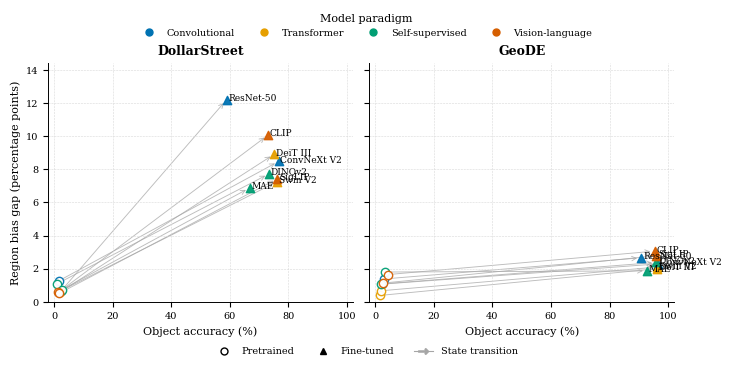

In [17]:
try:
    from adjustText import adjust_text
    USE_ADJUST_TEXT = True
except ImportError:
    USE_ADJUST_TEXT = False

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
})

model_name_map = {
    "ConvNeXt V2": "ConvNeXt V2",
    "ConvNeXtV2": "ConvNeXt V2",
    "convnextv2": "ConvNeXt V2",

    "ResNet-50": "ResNet-50",
    "ResNet50": "ResNet-50",
    "resnet50": "ResNet-50",

    "Swin V2": "Swin V2",
    "SwinV2": "Swin V2",
    "swinv2": "Swin V2",

    "DeiT III": "DeiT III",
    "DeiT3": "DeiT III",
    "deit3": "DeiT III",

    "DINOv2": "DINOv2",
    "dinov2": "DINOv2",

    "MAE": "MAE",
    "mae": "MAE",

    "CLIP": "CLIP",
    "clip": "CLIP",

    "SigLIP": "SigLIP",
    "siglip": "SigLIP",
}

paradigm_map = {
    "ResNet-50": "Convolutional",
    "ConvNeXt V2": "Convolutional",

    "Swin V2": "Transformer",
    "DeiT III": "Transformer",

    "DINOv2": "Self-supervised",
    "MAE": "Self-supervised",

    "CLIP": "Vision-language",
    "SigLIP": "Vision-language",
}

# Colorblind-friendly palette
paradigm_colors = {
    "Convolutional": "#0072B2",
    "Transformer": "#E69F00",
    "Self-supervised": "#009E73",
    "Vision-language": "#D55E00",
}

state_markers = {
    "Pretrained": "o",
    "Fine-tuned": "^",
}

plot_df = results.copy()

plot_df["dataset"] = plot_df["dataset"].astype(str).str.lower()
plot_df["model"] = plot_df["model"].replace(model_name_map)

plot_df["finetune"] = plot_df["finetune"].astype(str).str.lower()
plot_df["state"] = np.where(plot_df["finetune"].eq("yes"), "Fine-tuned", "Pretrained")

plot_df["paradigm"] = plot_df["model"].map(paradigm_map)

for col in ["object_acc", "region_bias_gap"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

if plot_df["object_acc"].max() <= 1.5:
    plot_df["object_acc"] = plot_df["object_acc"] * 100

if plot_df["region_bias_gap"].max() <= 1.5:
    plot_df["region_bias_gap"] = plot_df["region_bias_gap"] * 100

plot_df = plot_df.dropna(subset=["object_acc", "region_bias_gap", "paradigm"])

def plot_accuracy_disparity_tradeoff(data, save_path=None):
    datasets = ["dollarstreet", "geode"]
    dataset_titles = {
        "dollarstreet": "DollarStreet",
        "geode": "GeoDE",
    }
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.0),
        sharey=True,
        constrained_layout=True
    )
    y_max = data["region_bias_gap"].max() * 1.18
    for ax, dataset_name in zip(axes, datasets):
        d = data[data["dataset"] == dataset_name].copy()
        for model in d["model"].unique():
            m = d[d["model"] == model]

            if {"Pretrained", "Fine-tuned"}.issubset(set(m["state"])):
                p0 = m[m["state"] == "Pretrained"].iloc[0]
                p1 = m[m["state"] == "Fine-tuned"].iloc[0]

                ax.annotate(
                    "",
                    xy=(p1["object_acc"], p1["region_bias_gap"]),
                    xytext=(p0["object_acc"], p0["region_bias_gap"]),
                    arrowprops=dict(
                        arrowstyle="->",
                        color="0.65",
                        lw=0.65,
                        alpha=0.75,
                        shrinkA=3,
                        shrinkB=3,
                    ),
                    zorder=1
                )
        for paradigm, color in paradigm_colors.items():
            for state, marker in state_markers.items():
                sub = d[(d["paradigm"] == paradigm) & (d["state"] == state)]
                if sub.empty:
                    continue
                facecolor = "white" if state == "Pretrained" else color
                ax.scatter(
                    sub["object_acc"],
                    sub["region_bias_gap"],
                    s=36,
                    marker=marker,
                    facecolors=facecolor,
                    edgecolors=color,
                    linewidths=1.0,
                    alpha=0.95,
                    zorder=3
                )
        texts = []
        ft = d[d["state"] == "Fine-tuned"]
        for _, row in ft.iterrows():
            texts.append(
                ax.text(
                    row["object_acc"] + 0.6,
                    row["region_bias_gap"] + 0.08,
                    row["model"],
                    fontsize=6.5,
                    ha="left",
                    va="center"
                )
            )
        if USE_ADJUST_TEXT and len(texts) > 0:
            adjust_text(
                texts,
                ax=ax,
                arrowprops=dict(
                    arrowstyle="-",
                    color="0.65",
                    lw=0.35,
                    alpha=0.6
                )
            )
        ax.set_title(dataset_titles[dataset_name], fontweight="bold")
        ax.set_xlabel("Object accuracy (%)")
        ax.set_xlim(-2, 102)
        ax.set_ylim(0, y_max)
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.4,
            color="0.85",
            zorder=0
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].set_ylabel("Region bias gap (percentage points)")
    paradigm_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=5,
            label=paradigm
        )
        for paradigm, color in paradigm_colors.items()
    ]
    state_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            markerfacecolor="white",
            markersize=5,
            linestyle="None",
            label="Pretrained"
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="black",
            markerfacecolor="black",
            markersize=5,
            linestyle="None",
            label="Fine-tuned"
        ),
        Line2D(
            [0], [0],
            color="0.65",
            lw=0.8,
            marker=r"$\rightarrow$",
            markersize=7,
            label="State transition"
        ),
    ]
    fig.legend(
        handles=paradigm_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=4,
        frameon=False,
        title="Model paradigm",
        title_fontsize=8
    )
    fig.legend(
        handles=state_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False
    )
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        fig.savefig(save_path.replace(".pdf", ".png"), dpi=600, bbox_inches="tight")
        fig.savefig(save_path.replace(".pdf", ".svg"), bbox_inches="tight")

    plt.show()

plot_accuracy_disparity_tradeoff(
    plot_df,
    save_path="figures/accuracy_disparity_tradeoff_paper.pdf"
)

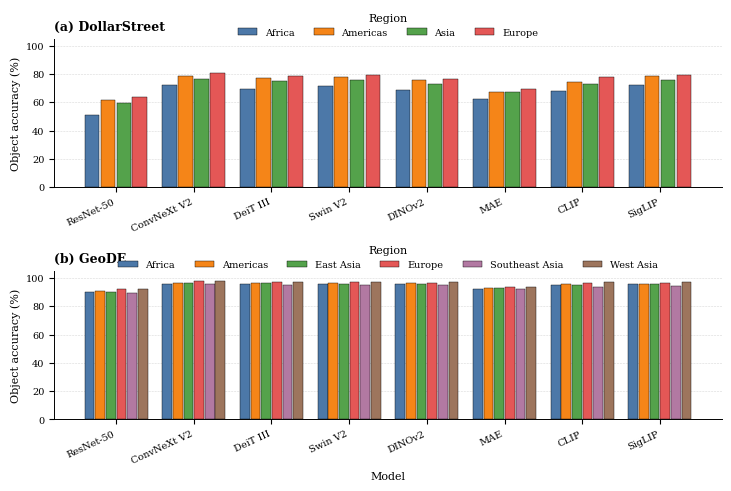

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Paper-style rcParams
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
})

# =========================================================
# 2. Consistent model order
# =========================================================
model_order = [
    "ResNet-50",
    "ConvNeXt V2",
    "DeiT III",
    "Swin V2",
    "DINOv2",
    "MAE",
    "CLIP",
    "SigLIP",
]

model_map = {
    "ResNet50": "ResNet-50",
    "ResNet-50": "ResNet-50",
    "ConvNeXtV2": "ConvNeXt V2",
    "ConvNeXt V2": "ConvNeXt V2",
    "DeiT3": "DeiT III",
    "DeiT III": "DeiT III",
    "SwinV2": "Swin V2",
    "Swin V2": "Swin V2",
    "DINOv2": "DINOv2",
    "MAE": "MAE",
    "CLIP": "CLIP",
    "SigLIP": "SigLIP",
}

region_display_map = {
    "EastAsia": "East Asia",
    "SouthEastAsia": "Southeast Asia",
    "WestAsia": "West Asia",
    "Africa": "Africa",
    "Americas": "Americas",
    "Asia": "Asia",
    "Europe": "Europe",
}

# =========================================================
# 3. Clean solid colors only
# =========================================================
region_colors = {
    "Africa": "#4C78A8",
    "Americas": "#F58518",
    "Asia": "#54A24B",
    "Europe": "#E45756",
    "East Asia": "#54A24B",
    "Southeast Asia": "#B279A2",
    "West Asia": "#9D755D",
}

# =========================================================
# 4. Helper
# =========================================================
def prepare_wide_df(df):
    df = df.copy()
    df["model"] = df["model"].replace(model_map)
    df["dataset"] = df["dataset"].astype(str).str.lower()
    return df

# =========================================================
# 5. Plot one grouped bar chart
# =========================================================
def plot_grouped_bars_from_wide(ax, df, dataset_name, panel_label):
    df = prepare_wide_df(df)

    if dataset_name == "dollarstreet":
        region_cols = ["Africa", "Americas", "Asia", "Europe"]
        title = f"{panel_label} DollarStreet"
    elif dataset_name == "geode":
        region_cols = ["Africa", "Americas", "EastAsia", "Europe", "SouthEastAsia", "WestAsia"]
        title = f"{panel_label} GeoDE"
    else:
        raise ValueError("dataset_name must be 'dollarstreet' or 'geode'")

    df = df.set_index("model").reindex(model_order).reset_index()

    x = np.arange(len(df))
    n_regions = len(region_cols)
    total_width = 0.82
    bar_width = total_width / n_regions

    for i, region in enumerate(region_cols):
        display_region = region_display_map.get(region, region)
        offset = (i - (n_regions - 1) / 2) * bar_width
        values = pd.to_numeric(df[region], errors="coerce").values

        ax.bar(
            x + offset,
            values,
            width=bar_width * 0.92,
            label=display_region,
            color=region_colors.get(display_region, "gray"),
            edgecolor="black",
            linewidth=0.3,
            zorder=3
        )

    ax.set_title(title, fontweight="bold", loc="left")
    ax.set_ylabel("Object accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(df["model"], rotation=25, ha="right")

    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 20))

    ax.grid(axis="y", linestyle="--", linewidth=0.4, color="0.85", zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Region",
        frameon=False,
        ncol=min(6, n_regions),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.23)
    )

# =========================================================
# 6. Two-panel figure
# =========================================================
def plot_two_dataset_region_bars(dollar_df, geode_df, save_path="figures/per_region_accuracy_by_model.pdf"):
    fig, axes = plt.subplots(
        2, 1,
        figsize=(7.2, 4.8),
        sharey=True,
        constrained_layout=True
    )

    plot_grouped_bars_from_wide(axes[0], dollar_df, "dollarstreet", "(a)")
    plot_grouped_bars_from_wide(axes[1], geode_df, "geode", "(b)")

    axes[1].set_xlabel("Model")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".svg"), bbox_inches="tight")

    plt.show()

plot_two_dataset_region_bars(
    dollar_df=dollarstreet_detailed,
    geode_df=geode_detailed,
    save_path="figures/finetuned_per_region_accuracy_by_model.pdf"
)

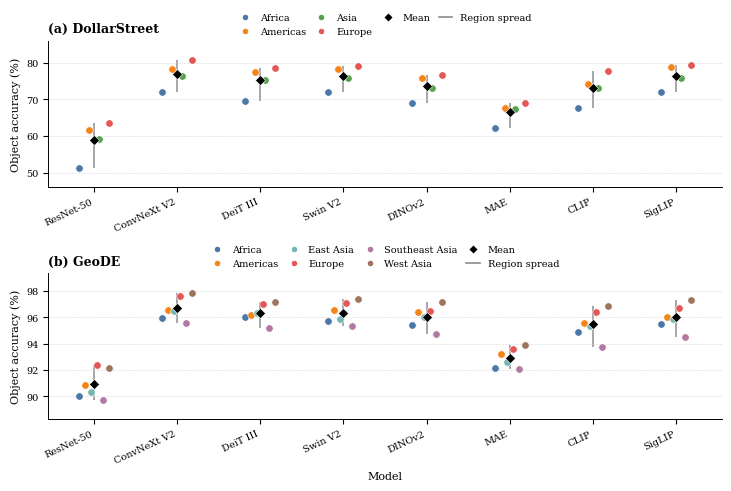

In [19]:
# =========================================================
# 1. Paper style
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
})

# =========================================================
# 2. Model and region settings
# =========================================================
model_order = [
    "ResNet-50",
    "ConvNeXt V2",
    "DeiT III",
    "Swin V2",
    "DINOv2",
    "MAE",
    "CLIP",
    "SigLIP",
]

model_map = {
    "ResNet50": "ResNet-50",
    "ResNet-50": "ResNet-50",
    "ConvNeXtV2": "ConvNeXt V2",
    "ConvNeXt V2": "ConvNeXt V2",
    "DeiT3": "DeiT III",
    "DeiT III": "DeiT III",
    "SwinV2": "Swin V2",
    "Swin V2": "Swin V2",
    "DINOv2": "DINOv2",
    "MAE": "MAE",
    "CLIP": "CLIP",
    "SigLIP": "SigLIP",
}

region_display_map = {
    "Africa": "Africa",
    "Americas": "Americas",
    "Asia": "Asia",
    "Europe": "Europe",
    "EastAsia": "East Asia",
    "SouthEastAsia": "Southeast Asia",
    "WestAsia": "West Asia",
}

region_colors = {
    "Africa": "#4C78A8",
    "Americas": "#F58518",
    "Asia": "#54A24B",
    "Europe": "#E45756",
    "East Asia": "#72B7B2",
    "Southeast Asia": "#B279A2",
    "West Asia": "#9D755D",
}

region_orders = {
    "dollarstreet": ["Africa", "Americas", "Asia", "Europe"],
    "geode": ["Africa", "Americas", "EastAsia", "Europe", "SouthEastAsia", "WestAsia"],
}

# =========================================================
# 3. Helper
# =========================================================
def prepare_wide_df(df):
    df = df.copy()
    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].replace(model_map)
    return df

# =========================================================
# 4. Plot one dataset
# =========================================================
def plot_region_spread(ax, df, dataset_name, panel_label):
    df = prepare_wide_df(df)

    region_cols = region_orders[dataset_name]

    df = df.set_index("model").reindex(model_order).reset_index()

    x = np.arange(len(df))
    offsets = np.linspace(-0.18, 0.18, len(region_cols))

    all_values = []

    for i, row in df.iterrows():
        values = pd.to_numeric(row[region_cols], errors="coerce").values.astype(float)

        # Convert to percentage if values are in [0, 1]
        if np.nanmax(values) <= 1.5:
            values = values * 100

        all_values.extend(values)

        min_acc = np.nanmin(values)
        max_acc = np.nanmax(values)
        mean_acc = np.nanmean(values)

        # Vertical spread line: worst region -> best region
        ax.vlines(
            x=i,
            ymin=min_acc,
            ymax=max_acc,
            color="0.55",
            linewidth=1.2,
            alpha=0.9,
            zorder=1
        )

        # Region points
        for j, region in enumerate(region_cols):
            display_region = region_display_map[region]

            ax.scatter(
                i + offsets[j],
                values[j],
                s=28,
                color=region_colors[display_region],
                edgecolor="white",
                linewidth=0.4,
                zorder=3
            )

        # Mean accuracy marker
        ax.scatter(
            i,
            mean_acc,
            s=26,
            marker="D",
            color="black",
            edgecolor="white",
            linewidth=0.4,
            zorder=4
        )

    # Automatic y-limit per dataset
    all_values = np.array(all_values, dtype=float)
    y_min = np.nanmin(all_values)
    y_max = np.nanmax(all_values)
    pad = (y_max - y_min) * 0.18

    ax.set_ylim(max(0, y_min - pad), min(100, y_max + pad))

    dataset_title = {
        "dollarstreet": "DollarStreet",
        "geode": "GeoDE",
    }[dataset_name]

    ax.set_title(f"{panel_label} {dataset_title}", loc="left", fontweight="bold")
    ax.set_ylabel("Object accuracy (%)")

    ax.set_xticks(x)
    ax.set_xticklabels(df["model"], rotation=25, ha="right")

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.4,
        color="0.85",
        zorder=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    region_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=region_colors[region_display_map[r]],
            markeredgecolor="white",
            markersize=5,
            label=region_display_map[r]
        )
        for r in region_cols
    ]

    mean_handle = Line2D(
        [0], [0],
        marker="D",
        color="none",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=5,
        label="Mean"
    )

    spread_handle = Line2D(
        [0], [0],
        color="0.55",
        linewidth=1.2,
        label="Region spread"
    )

    ax.legend(
        handles=region_handles + [mean_handle, spread_handle],
        frameon=False,
        ncol=min(4, len(region_cols)),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        columnspacing=0.9,
        handlelength=1.4
    )

# =========================================================
# 5. Two-panel paper figure
# =========================================================
def plot_two_dataset_region_spread(
    dollar_df,
    geode_df,
    save_path="figures/region_spread_by_model.pdf"
):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(7.2, 4.8),
        constrained_layout=True
    )

    plot_region_spread(axes[0], dollar_df, "dollarstreet", "(a)")
    plot_region_spread(axes[1], geode_df, "geode", "(b)")

    axes[1].set_xlabel("Model")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".svg"), bbox_inches="tight")

    plt.show()

# =========================================================
# 6. Run
# =========================================================
plot_two_dataset_region_spread(
    dollar_df=dollarstreet_detailed,
    geode_df=geode_detailed,
    save_path="figures/region_spread_by_model.pdf"
)

C:\Users\VUONG\AppData\Local\Temp\ipykernel_8136\470334627.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


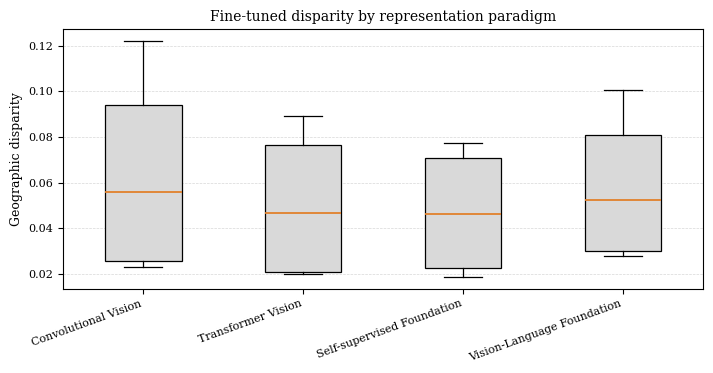

In [20]:
# =========================================================
# 1. Paper-style settings
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
})

# =========================================================
# 2. Model -> paradigm mapping
# =========================================================
model_map = {
    "ResNet50": "ResNet-50",
    "ResNet-50": "ResNet-50",
    "ConvNeXtV2": "ConvNeXt V2",
    "ConvNeXt V2": "ConvNeXt V2",
    "DeiT3": "DeiT III",
    "DeiT III": "DeiT III",
    "SwinV2": "Swin V2",
    "Swin V2": "Swin V2",
    "DINOv2": "DINOv2",
    "MAE": "MAE",
    "CLIP": "CLIP",
    "SigLIP": "SigLIP",
}

paradigm_map = {
    "ResNet-50": "Convolutional Vision",
    "ConvNeXt V2": "Convolutional Vision",

    "DeiT III": "Transformer Vision",
    "Swin V2": "Transformer Vision",

    "DINOv2": "Self-supervised Foundation",
    "MAE": "Self-supervised Foundation",

    "CLIP": "Vision-Language Foundation",
    "SigLIP": "Vision-Language Foundation",
}

paradigm_order = [
    "Convolutional Vision",
    "Transformer Vision",
    "Self-supervised Foundation",
    "Vision-Language Foundation",
]

# =========================================================
# 3. Prepare data
# =========================================================
plot_df = results.copy()

plot_df["model"] = plot_df["model"].replace(model_map)
plot_df["finetune"] = plot_df["finetune"].astype(str).str.lower()

# keep only finetuned
plot_df = plot_df[plot_df["finetune"] == "yes"].copy()

plot_df["region_bias_gap"] = pd.to_numeric(plot_df["region_bias_gap"], errors="coerce")
plot_df["paradigm"] = plot_df["model"].map(paradigm_map)

plot_df = plot_df.dropna(subset=["region_bias_gap", "paradigm"])

# if your gap is stored in percentages like 10.07, convert to proportion
# comment this out if your values are already 0.10, 0.08, ...
if plot_df["region_bias_gap"].max() > 1:
    plot_df["region_bias_gap"] = plot_df["region_bias_gap"] / 100.0

# create grouped data for boxplot
grouped_data = [
    plot_df.loc[plot_df["paradigm"] == p, "region_bias_gap"].values
    for p in paradigm_order
]

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7.2, 3.8))

bp = ax.boxplot(
    grouped_data,
    labels=paradigm_order,
    patch_artist=True,
    widths=0.48,
    medianprops=dict(color="#E1812C", linewidth=1.3),
    boxprops=dict(facecolor="#D9D9D9", edgecolor="black", linewidth=0.9),
    whiskerprops=dict(color="black", linewidth=0.9),
    capprops=dict(color="black", linewidth=0.9),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4,
        linestyle="none"
    )
)

ax.set_title("Fine-tuned disparity by representation paradigm", pad=6)
ax.set_ylabel("Geographic disparity")

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

plt.xticks(rotation=20, ha="right")

# optional: cleaner spines
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

plt.tight_layout()

# =========================================================
# 5. Save
# =========================================================
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/finetuned_disparity_by_paradigm.pdf", bbox_inches="tight")
plt.savefig("figures/finetuned_disparity_by_paradigm.png", dpi=600, bbox_inches="tight")
plt.savefig("figures/finetuned_disparity_by_paradigm.svg", bbox_inches="tight")

plt.show()

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

os.makedirs("figures", exist_ok=True)

# =========================================================
# 1. Paper style
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.7,
})

# =========================================================
# 2. Model / paradigm mapping
# =========================================================
model_order = [
    "ResNet-50",
    "ConvNeXt V2",
    "DeiT III",
    "Swin V2",
    "MaxViT",
    "DINOv2",
    "MAE",
    "CLIP",
    "SigLIP",
]

model_map = {
    "ResNet50": "ResNet-50",
    "ResNet-50": "ResNet-50",
    "ConvNeXtV2": "ConvNeXt V2",
    "ConvNeXt V2": "ConvNeXt V2",
    "DeiT3": "DeiT III",
    "DeiT III": "DeiT III",
    "SwinV2": "Swin V2",
    "Swin V2": "Swin V2",
    "DINOv2": "DINOv2",
    "MAE": "MAE",
    "MaxViT": "MaxViT",
    "CLIP": "CLIP",
    "SigLIP": "SigLIP",
}

paradigm_map = {
    "ResNet-50": "Convolutional",
    "ConvNeXt V2": "Convolutional",

    "DeiT III": "Transformer",
    "Swin V2": "Transformer",
    "MaxViT": "Transformer",

    "DINOv2": "Self-supervised",
    "MAE": "Self-supervised",

    "CLIP": "Vision-language",
    "SigLIP": "Vision-language",
}

paradigm_colors = {
    "Convolutional": "#4C78A8",
    "Transformer": "#F58518",
    "Self-supervised": "#54A24B",
    "Vision-language": "#E45756",
}

state_markers = {
    "Pretrained": "o",
    "Fine-tuned": "^",
}


# =========================================================
# 3. Prepare dataframe
# =========================================================
def prepare_results_df(df):
    df = df.copy()

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].replace(model_map)

    df["finetune"] = df["finetune"].astype(str).str.lower()
    df["state"] = np.where(df["finetune"].eq("yes"), "Fine-tuned", "Pretrained")

    for col in ["loss", "object_acc", "best_region_acc", "worst_region_acc", "region_bias_gap"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["best_region"] = df["best_region"].replace({
        "America": "Americas",
    })

    df["worst_region"] = df["worst_region"].replace({
        "America": "Americas",
    })

    df["paradigm"] = df["model"].map(paradigm_map)

    return df


results_df = prepare_results_df(results)

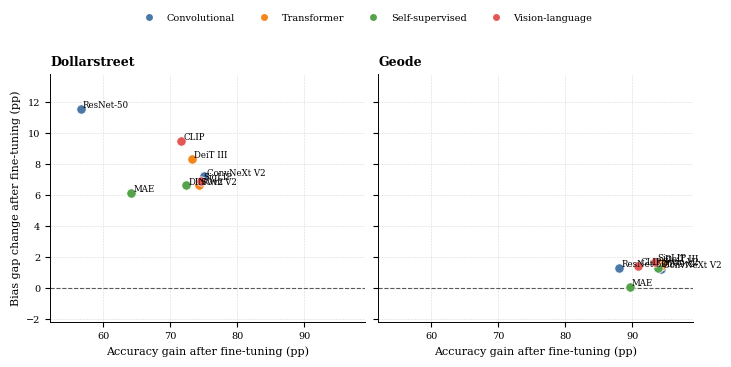

In [22]:
def plot_finetuning_effect(
    df,
    save_path="figures/finetuning_effect_delta_plot.pdf"
):
    pre = (
        df[df["state"] == "Pretrained"]
        .set_index(["dataset", "model", "paradigm"])
        [["object_acc", "region_bias_gap"]]
        .rename(columns={
            "object_acc": "object_acc_pre",
            "region_bias_gap": "gap_pre"
        })
    )

    ft = (
        df[df["state"] == "Fine-tuned"]
        .set_index(["dataset", "model", "paradigm"])
        [["object_acc", "region_bias_gap"]]
        .rename(columns={
            "object_acc": "object_acc_ft",
            "region_bias_gap": "gap_ft"
        })
    )

    delta_df = pre.join(ft, how="inner").reset_index()

    delta_df["delta_acc"] = delta_df["object_acc_ft"] - delta_df["object_acc_pre"]
    delta_df["delta_gap"] = delta_df["gap_ft"] - delta_df["gap_pre"]

    dataset_order = [d for d in ["dollarstreet", "geode"] if d in delta_df["dataset"].unique()]

    fig, axes = plt.subplots(
        1,
        len(dataset_order),
        figsize=(7.2, 3.1),
        sharey=True,
        constrained_layout=True
    )

    if len(dataset_order) == 1:
        axes = [axes]

    x_min = delta_df["delta_acc"].min()
    x_max = delta_df["delta_acc"].max()
    y_min = delta_df["delta_gap"].min()
    y_max = delta_df["delta_gap"].max()

    x_pad = (x_max - x_min) * 0.12
    y_pad = (y_max - y_min) * 0.20

    for ax, dataset_name in zip(axes, dataset_order):
        d = delta_df[delta_df["dataset"] == dataset_name].copy()

        ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--")
        ax.axvline(0, color="0.35", linewidth=0.8, linestyle="--")

        for paradigm, color in paradigm_colors.items():
            sub = d[d["paradigm"] == paradigm]

            if sub.empty:
                continue

            ax.scatter(
                sub["delta_acc"],
                sub["delta_gap"],
                s=45,
                color=color,
                edgecolor="white",
                linewidth=0.5,
                zorder=3
            )

        for _, row in d.iterrows():
            ax.text(
                row["delta_acc"] + 0.35,
                row["delta_gap"] + 0.08,
                row["model"],
                fontsize=6.2
            )

        ax.set_title(dataset_name.capitalize(), loc="left", fontweight="bold")
        ax.set_xlabel("Accuracy gain after fine-tuning (pp)")

        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        ax.grid(axis="both", linestyle="--", linewidth=0.4, color="0.85")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Bias gap change after fine-tuning (pp)")

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=color,
            markeredgecolor="white",
            markersize=6,
            label=paradigm
        )
        for paradigm, color in paradigm_colors.items()
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=4,
        frameon=False
    )

    fig.savefig(save_path, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(save_path.replace(".pdf", ".svg"), bbox_inches="tight")

    plt.show()


plot_finetuning_effect(results_df)

In [23]:
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe

GeoDE summary
split          region  train   val  test  total
0              Africa   4970  3575  3576  12121
1            Americas   4970  2336  2337   9643
2           East Asia   4970  2388  2389   9747
3              Europe   4970  3070  3071  11111
4      Southeast Asia   4970  2790  2791  10551
5           West Asia   4970  1891  1891   8752

DollarStreet summary
split    region  train   val  test  total
0        Africa   2481   825   847   4153
1      Americas   2538   846   856   4240
2          Asia   5889  1965  1919   9773
3        Europe   2011   673   686   3370


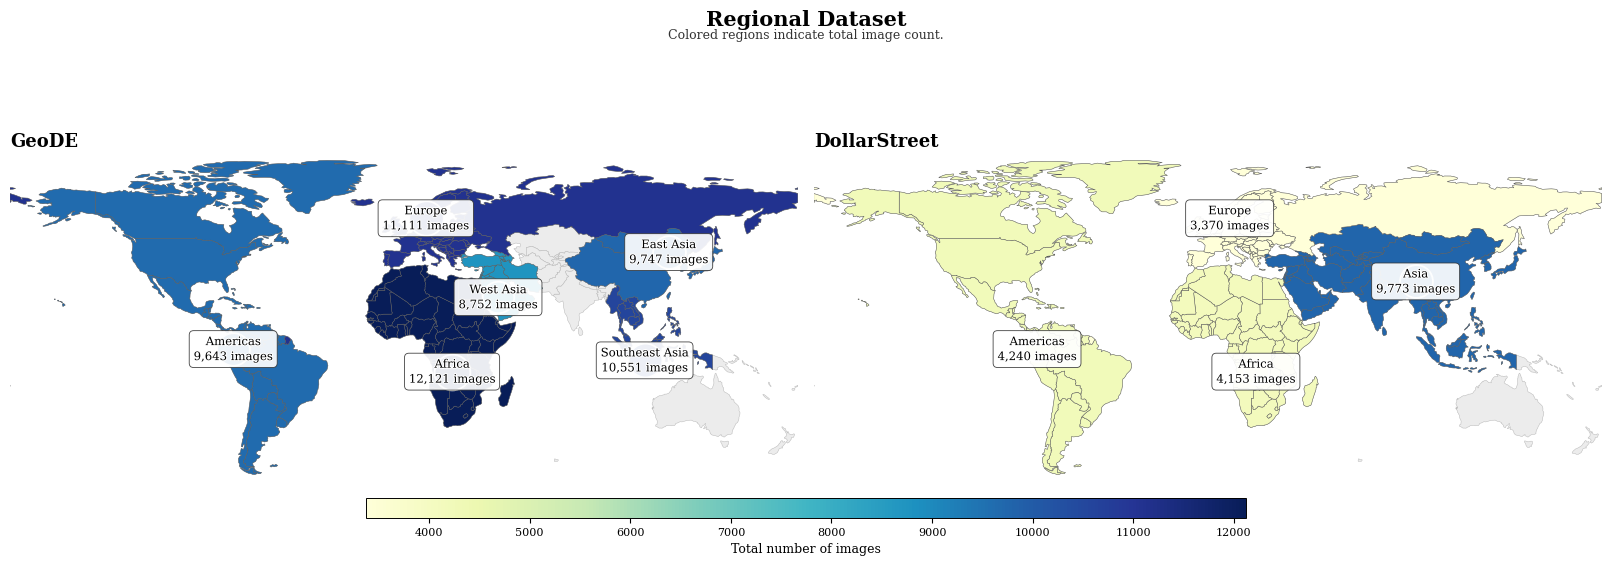

In [24]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe

# =========================================================
# 1. CONFIG
# =========================================================
GEODE_ROOT = Path(r"D:\Project\DAP_paper\datasets\processed\GeoDE")
DOLLAR_ROOT = Path(r"D:\Project\DAP_paper\datasets\processed\DollarStreet")

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# =========================================================
# 2. PAPER STYLE
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 13,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# 3. REGION NAME FIXES
# =========================================================
GEODE_REGION_MAP = {
    "Africa": "Africa",
    "Americas": "Americas",
    "Europe": "Europe",
    "EastAsia": "East Asia",
    "SouthEastAsia": "Southeast Asia",
    "WestAsia": "West Asia",
}

DOLLAR_REGION_MAP = {
    "af": "Africa",
    "am": "Americas",
    "as": "Asia",
    "eu": "Europe",
}

# =========================================================
# 4. COUNT IMAGES FROM DIRECTORY
# =========================================================
def count_region_images(dataset_root, dataset_name, region_map=None):
    """
    Expected structure:

    dataset_root/
        train/
            region/
                class/
                    image.jpg
        val/
            region/
                class/
                    image.jpg
        test/
            region/
                class/
                    image.jpg
    """

    dataset_root = Path(dataset_root)

    if region_map is None:
        region_map = {}

    rows = []

    for split in ["train", "val", "test"]:
        split_dir = dataset_root / split

        if not split_dir.exists():
            print(f"[WARNING] Split folder not found: {split_dir}")
            continue

        for region_dir in split_dir.iterdir():
            if not region_dir.is_dir():
                continue

            original_region = region_dir.name
            mapped_region = region_map.get(original_region, original_region)

            count = 0

            for p in region_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                    count += 1

            rows.append({
                "dataset": dataset_name,
                "split": split,
                "region": mapped_region,
                "count": count
            })

    return pd.DataFrame(rows)

# =========================================================
# 5. SUMMARIZE COUNTS
# =========================================================
def summarize_region_counts(count_df):
    summary = (
        count_df
        .pivot_table(
            index="region",
            columns="split",
            values="count",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    for split in ["train", "val", "test"]:
        if split not in summary.columns:
            summary[split] = 0

    summary["total"] = summary[["train", "val", "test"]].sum(axis=1)

    summary = summary[["region", "train", "val", "test", "total"]]

    return summary

# =========================================================
# 6. LOAD WORLD MAP
# =========================================================
def load_world():
    """
    Compatible with GeoPandas >= 1.0.
    Uses Natural Earth country polygons.
    """

    world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

    world = gpd.read_file(world_url)

    # Robust column normalization
    lower_cols = {c.lower(): c for c in world.columns}

    rename_cols = {}

    if "admin" in lower_cols:
        rename_cols[lower_cols["admin"]] = "name"
    elif "name" in lower_cols:
        rename_cols[lower_cols["name"]] = "name"

    if "continent" in lower_cols:
        rename_cols[lower_cols["continent"]] = "continent"

    world = world.rename(columns=rename_cols)

    world = world[world["name"] != "Antarctica"].copy()
    world = world.to_crs("EPSG:4326")

    return world

# =========================================================
# 7. GEO REGION ASSIGNMENT
# =========================================================
EAST_ASIA = {
    "China",
    "Japan",
    "Mongolia",
    "North Korea",
    "South Korea",
    "Taiwan",
}

SOUTHEAST_ASIA = {
    "Myanmar",
    "Thailand",
    "Laos",
    "Lao PDR",
    "Cambodia",
    "Vietnam",
    "Viet Nam",
    "Malaysia",
    "Singapore",
    "Indonesia",
    "Philippines",
    "Brunei",
    "Brunei Darussalam",
    "Timor-Leste",
    "Timor Leste",
}

WEST_ASIA = {
    "Turkey",
    "Cyprus",
    "Georgia",
    "Armenia",
    "Azerbaijan",
    "Syria",
    "Lebanon",
    "Israel",
    "Jordan",
    "Iraq",
    "Iran",
    "Saudi Arabia",
    "Yemen",
    "Oman",
    "United Arab Emirates",
    "Qatar",
    "Bahrain",
    "Kuwait",
    "Palestine",
    "Palestinian Territory",
}

def assign_region_geode(row):
    country = row["name"]
    continent = row["continent"]

    if continent == "Africa":
        return "Africa"

    if continent in ["North America", "South America"]:
        return "Americas"

    if continent == "Europe":
        return "Europe"

    if country in EAST_ASIA:
        return "East Asia"

    if country in SOUTHEAST_ASIA:
        return "Southeast Asia"

    if country in WEST_ASIA:
        return "West Asia"

    return None

def assign_region_dollarstreet(row):
    continent = row["continent"]

    if continent == "Africa":
        return "Africa"

    if continent in ["North America", "South America"]:
        return "Americas"

    if continent == "Europe":
        return "Europe"

    if continent == "Asia":
        return "Asia"

    return None

# =========================================================
# 8. LABEL POSITIONS
# =========================================================
GEODE_LABEL_POS = {
    "Africa": (22, -10),
    "Americas": (-78, 0),
    "Europe": (10, 58),
    "East Asia": (121, 43),
    "Southeast Asia": (110, -5),
    "West Asia": (43, 23),
}

DOLLAR_LABEL_POS = {
    "Africa": (22, -10),
    "Americas": (-78, 0),
    "Europe": (10, 58),
    "Asia": (95, 30),
}

# =========================================================
# 9. FANCY MAP FUNCTION
# =========================================================
def plot_fancy_region_count_map(
    world,
    summary_df,
    dataset_name,
    assign_fn,
    label_positions,
    ax,
    cmap,
    norm,
    global_max_total
):
    summary_df = summary_df.copy()

    region_to_total = dict(zip(summary_df["region"], summary_df["total"]))

    world_plot = world.copy()
    world_plot["region"] = world_plot.apply(assign_fn, axis=1)
    world_plot["value"] = world_plot["region"].map(region_to_total)

    # Ocean background
    ax.set_facecolor("#F6FAFF")

    # Base map
    world_plot.plot(
        ax=ax,
        color="#ECECEC",
        edgecolor="#B8B8B8",
        linewidth=0.35,
        zorder=1
    )

    # Colored regions
    colored = world_plot.dropna(subset=["value"])

    if colored.empty:
        print(f"[WARNING] No colored regions for {dataset_name}")
    else:
        colored.plot(
            ax=ax,
            column="value",
            cmap=cmap,
            vmin=norm.vmin,
            vmax=norm.vmax,
            edgecolor="#5C5C5C",
            linewidth=0.35,
            zorder=2
        )

    # Region labels
    summary_indexed = summary_df.set_index("region")

    for region, (x, y) in label_positions.items():
        if region not in summary_indexed.index:
            continue

        r = summary_indexed.loc[region]

        total = int(r["total"])

        # Bubble size based on global total count
        bubble_size = 140 + 520 * (total / global_max_total)

        ax.scatter(
            x,
            y,
            s=bubble_size,
            color=cmap(norm(total)),
            edgecolor="white",
            linewidth=1.3,
            alpha=0.95,
            zorder=4
        )

        label = (
            f"{region}\n"
            f"{total:,} images"
        )

        text = ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=8.4,
            color="black",
            zorder=5,
            bbox=dict(
                boxstyle="round,pad=0.38",
                facecolor="white",
                edgecolor="#333333",
                linewidth=0.6,
                alpha=0.92
            )
        )

        text.set_path_effects([
            pe.withStroke(linewidth=1.4, foreground="white")
        ])

    ax.set_xlim(-180, 180)
    ax.set_ylim(-58, 85)

    ax.set_title(
        dataset_name,
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=8
    )

    ax.set_axis_off()

# =========================================================
# 10. COUNT DATASET IMAGES
# =========================================================
geode_counts = count_region_images(
    dataset_root=GEODE_ROOT,
    dataset_name="GeoDE",
    region_map=GEODE_REGION_MAP
)

dollar_counts = count_region_images(
    dataset_root=DOLLAR_ROOT,
    dataset_name="DollarStreet",
    region_map=DOLLAR_REGION_MAP
)

geode_summary = summarize_region_counts(geode_counts)
dollar_summary = summarize_region_counts(dollar_counts)

print("GeoDE summary")
print(geode_summary)

print("\nDollarStreet summary")
print(dollar_summary)

# =========================================================
# 11. CREATE LEFT-RIGHT FIGURE
# =========================================================
world = load_world()

all_totals = pd.concat([
    geode_summary["total"],
    dollar_summary["total"]
])

vmin = all_totals.min()
vmax = all_totals.max()

cmap = plt.get_cmap("YlGnBu")
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5.2),
    constrained_layout=True
)

plot_fancy_region_count_map(
    world=world,
    summary_df=geode_summary,
    dataset_name="GeoDE",
    assign_fn=assign_region_geode,
    label_positions=GEODE_LABEL_POS,
    ax=axes[0],
    cmap=cmap,
    norm=norm,
    global_max_total=vmax
)

plot_fancy_region_count_map(
    world=world,
    summary_df=dollar_summary,
    dataset_name="DollarStreet",
    assign_fn=assign_region_dollarstreet,
    label_positions=DOLLAR_LABEL_POS,
    ax=axes[1],
    cmap=cmap,
    norm=norm,
    global_max_total=vmax
)

# Main title
fig.suptitle(
    "Regional Dataset",
    fontsize=15,
    fontweight="bold",
    y=1.06
)

fig.text(
    0.5,
    1.005,
    "Colored regions indicate total image count.",
    ha="center",
    fontsize=9,
    color="#333333"
)

# Shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.045,
    pad=0.04,
    aspect=45
)

cbar.set_label("Total number of images", fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Save
plt.savefig(
    OUTPUT_DIR / "dataset_region_count_maps_left_right.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    OUTPUT_DIR / "dataset_region_count_maps_left_right.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUTPUT_DIR / "dataset_region_count_maps_left_right.svg",
    bbox_inches="tight"
)

plt.show()